# Stage 3. Conjunctiva Segmentation

Notebook ini melatih U-Net pada foto mata utuh Eyes-Defy untuk memprediksi mask konjungtiva palpebral, lalu mengevaluasi kualitas segmentasi memakai Dice dan IoU serta menampilkan contoh overlay. Segmentasi ini menjadi jembatan dari citra mentah menuju region of interest pada mode capture di lapangan.

## Environment Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import torch
from PIL import Image

from configs import paths
from src import data, segmentation

manifest = data.assign_stratified_split(data.build_manifest(save=False))
print("device", "cuda" if torch.cuda.is_available() else "cpu")

Eyes-Defy Italy melewati 2 folder tanpa metadata atau file lengkap: [93, 95]
Eyes-Defy India melewati 1 folder tanpa metadata atau file lengkap: [7]
device cuda


## Segmentation Datasets

Hanya baris Eyes-Defy yang dipakai karena memuat foto mata utuh dan mask palpebral. Foto dimuat dengan koreksi orientasi EXIF agar sejajar dengan mask.

In [2]:
train_ds, val_ds = segmentation.build_datasets(manifest, size=320)
print("train", len(train_ds), "val", len(val_ds))

train 151 val 64


## Train U-Net

Melatih U-Net dengan encoder ResNet34 pralatih ImageNet memakai kombinasi Dice loss dan binary cross entropy. Checkpoint terbaik disimpan berdasarkan Dice validasi.

In [3]:
result = segmentation.train_unet(manifest, size=320, epochs=25, batch_size=8)
print("best val dice", round(result["metrics"]["best_val_dice"], 4))
print("final val iou", round(result["metrics"]["final_val_iou"], 4))

epoch 01 train_loss 0.9336 val_dice 0.5629 val_iou 0.4075


epoch 02 train_loss 0.4827 val_dice 0.8217 val_iou 0.7020


epoch 03 train_loss 0.3321 val_dice 0.8231 val_iou 0.7040


epoch 04 train_loss 0.2878 val_dice 0.8068 val_iou 0.6846


epoch 05 train_loss 0.2866 val_dice 0.8078 val_iou 0.6833


...

epoch 21 train_loss 0.2017 val_dice 0.8380 val_iou 0.7255


epoch 22 train_loss 0.2054 val_dice 0.8446 val_iou 0.7356


epoch 23 train_loss 0.2074 val_dice 0.8427 val_iou 0.7326


epoch 24 train_loss 0.1947 val_dice 0.8366 val_iou 0.7234


epoch 25 train_loss 0.1923 val_dice 0.8411 val_iou 0.7303
best val dice 0.8449
final val iou 0.7303


## Training Curves

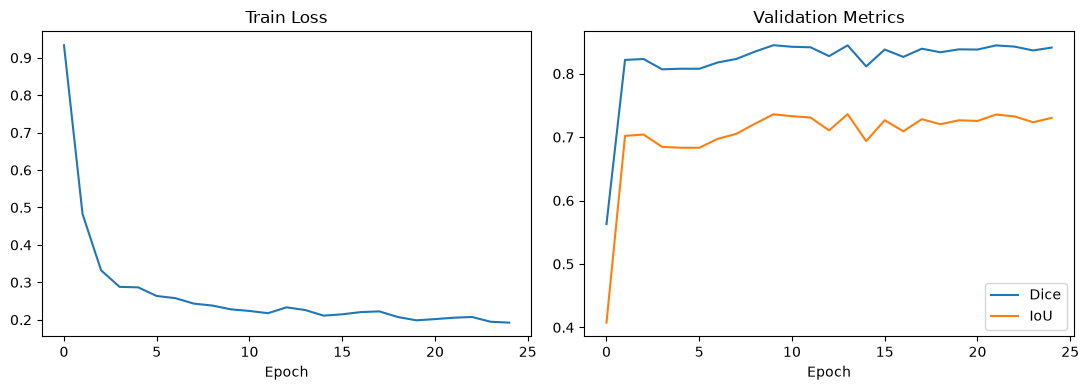

In [4]:
history = result["history"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(history["train_loss"])
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[1].plot(history["val_dice"], label="Dice")
axes[1].plot(history["val_iou"], label="IoU")
axes[1].set_title("Validation Metrics")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.show()

## Prediction Overlays

Overlay membandingkan citra, mask acuan, dan prediksi model pada data validasi.

overlays saved to /home/praktikan/projects/Azril/hemavision/outputs/segmentation_overlays.png


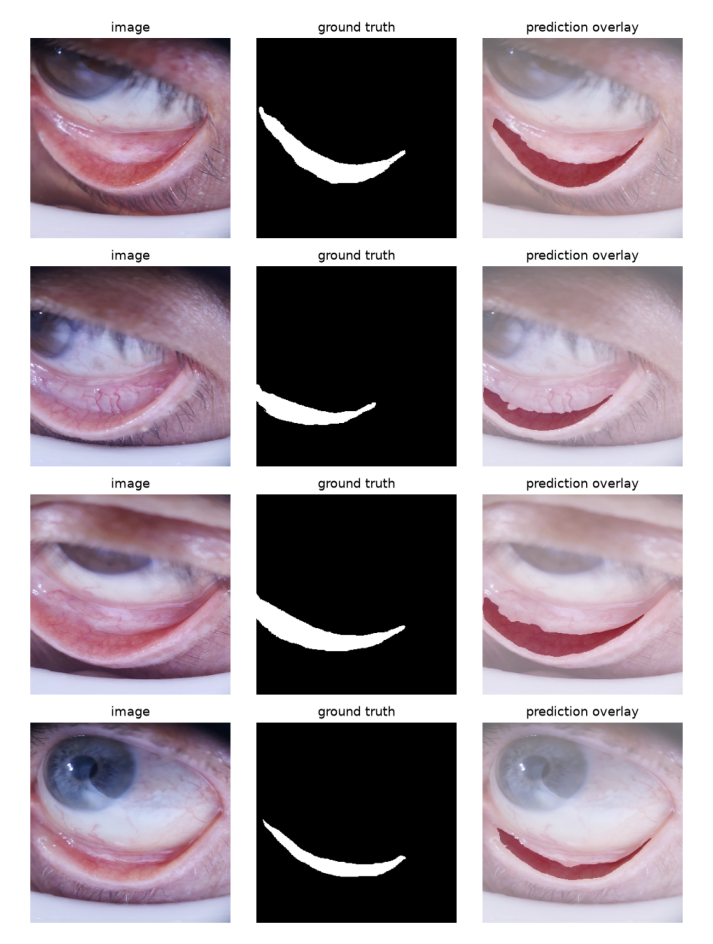

In [5]:
overlay_path = segmentation.save_overlays(result["model"], val_ds, count=4)
print("overlays saved to", overlay_path)
plt.figure(figsize=(9, 12))
plt.imshow(Image.open(overlay_path))
plt.axis("off")
plt.show()